In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [42]:
icecpl="/Users/max/ufs.cpld.cpl.hi.ice.2025-11-21-00000.nc"

In [43]:
ds = xr.open_dataset(icecpl)

In [44]:
print(ds)

<xarray.Dataset> Size: 49MB
Dimensions:                (time: 1, ntb: 2, iceImp_ny: 320, iceImp_nx: 360,
                            iceExp_ny: 320, iceExp_nx: 360,
                            Med_frac_ice_ny: 320, Med_frac_ice_nx: 360)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2025-11-21
Dimensions without coordinates: ntb, iceImp_ny, iceImp_nx, iceExp_ny,
                                iceExp_nx, Med_frac_ice_ny, Med_frac_ice_nx
Data variables: (12/54)
    time_bnds              (time, ntb) float64 16B ...
    iceImp_Faii_evap       (time, iceImp_ny, iceImp_nx) float64 922kB ...
    iceImp_Faii_lat        (time, iceImp_ny, iceImp_nx) float64 922kB ...
    iceImp_Faii_lwup       (time, iceImp_ny, iceImp_nx) float64 922kB ...
    iceImp_Faii_sen        (time, iceImp_ny, iceImp_nx) float64 922kB ...
    iceImp_Faii_taux       (time, iceImp_ny, iceImp_nx) float64 922kB ...
    ...                     ...
    iceExp_lon             (time, iceExp_ny, iceExp_nx) floa

In [48]:
vname="iceExp_Sa_tbot"

In [49]:
pdat = ds[vname].isel(time=0) 

In [52]:
vmin, vmax = 232, 310

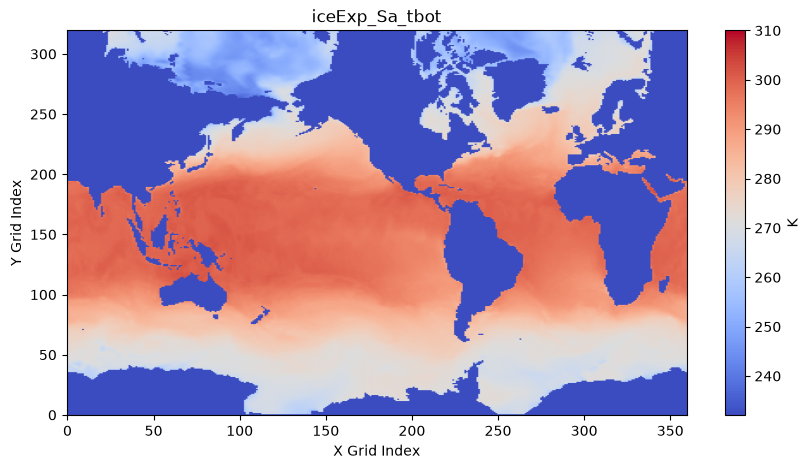

In [63]:
fig, ax = plt.subplots(figsize=(10, 5))


# Plot the raw numerical matrix data as pixels using standard imshow
# origin='lower' keeps index 0 at the bottom (South-to-North orientation)

img = ax.imshow(
    pdat.values, 
    cmap='coolwarm', 
    origin='lower', 
    vmin=vmin, 
    vmax=vmax,
    aspect='auto' 
)
# Add a colorbar and extract the labeled units directly from your data attributes
unit_label = pdat.attrs.get('units', 'Value')
cbar = fig.colorbar(img, ax=ax)
cbar.set_label(unit_label)

# Set final labels and title
ax.set_xlabel('X Grid Index')
ax.set_ylabel('Y Grid Index')
plt.title(f'{vname}')
plt.savefig('/Users/max/Desktop/iceExp_Sa_tbot.png', dpi=300, bbox_inches='tight')
plt.show()